<a href="https://colab.research.google.com/github/sharare-bazdar/Sharare-/blob/main/GRU_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import GRU, Dropout, Dense

In [ ]:
np.random.seed(42)
date_length=1000
temperatures=20+10*np.sin(np.linspace(0,3.14*4, date_length))+ np.random.normal(0,2,date_length)
data=pd.DataFrame(temperatures, columns=['temperature'])


In [ ]:
scaler=MinMaxScaler(feature_range=(0,1))
temperatures=scaler.fit_transform(data['temperature'].values.reshape(-1,1))


In [ ]:
def create_dataset(data, time_step=1):
  X,y=[],[]
  for i in range(len(data)-time_step-1):
    X.append(data[i:(i+time_step),0])
    y.append(data[i+time_step,0])
  return np.array(X), np.array(y)

In [ ]:
time_step=10
X, y=create_dataset(temperatures, time_step)

X=X.reshape(X.shape[0], X.shape[1],1)

model=Sequential()
model.add(GRU(50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))
model.add(GRU(50))
model.add(Dropout(0.2))
model.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [ ]:
model.fit(X,y ,epochs=100,batch_size=32)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1176
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0128
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0091
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0090
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0084
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0089
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0085
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0073
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0072
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0082
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0079
Epoch 12/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0081
Epoch 13/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0081
Epoch 14/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0081
Epoch 15/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - lo

In [ ]:
predicted_temperatures=model.predict(X)
predicted_temperatures=scaler.inverse_transform(predicted_temperatures)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


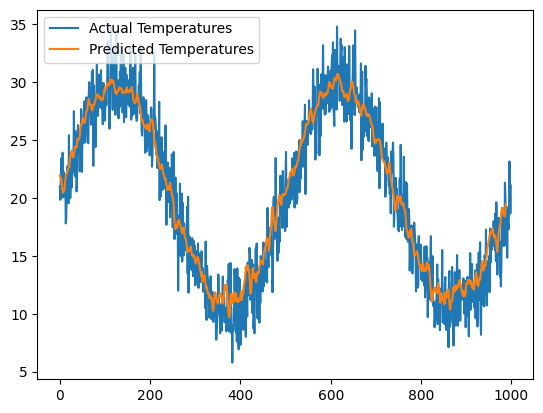

In [ ]:

plt.plot(data['temperature'].values,label='Actual Temperatures')
plt.plot(predicted_temperatures, label='Predicted Temperatures')
plt.legend()
plt.show()

In [ ]:
latest_data=temperatures[-time_step:]
latest_data=latest_data.reshape((1, time_step,1))

predicted_next_temperature=model.predict(latest_data)
predicted_next_temperature=scaler.inverse_transform(predicted_next_temperature)
print(f'Predicted temperature for the next time step:{predicted_next_temperature[0][0]:}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted temperature for the next time step:20.010656356811523
